In [110]:
!pip install requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import requests
import tensorflow as tf
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import to_categorical

from keras import models
from keras import layers


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Ig Al\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [79]:
df = pd.read_csv('friance new.csv')
df.head()

C:\Users\Ig Al\AppData\Local\Temp\ipykernel_16564\2458193486.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('friance new.csv')


,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,...,France,Germany,Spain,Female,Male,Mem__no__Products,Cred_Bal_Sal,Bal_sal,Tenure_Age,Age_Tenure_product
0,2023,668.0,33.0,3.0,0.00,2.0,1,0,181449.97,0,...,1,0,0,0,1,0.0,0.0,0.0,"9.090.909.090.909.090,00",99.0
1,2024,627.0,33.0,1.0,0.00,2.0,1,1,49503.5,0,...,1,0,0,0,1,2.0,0.0,0.0,"30.303.030.303.030.300,00",33.0
2,1236,678.0,40.0,10.0,0.00,2.0,1,0,184866.69,0,...,1,0,0,0,1,0.0,0.0,0.0,0.25,400.0
3,1362,581.0,34.0,2.0,148882.54,1.0,1,1,84560.88,0,...,1,0,0,0,1,1.0,"10.229.405.812.711.500,00","17.606.550.452.171.200,00","58.823.529.411.764.700,00",68.0
4,491,716.0,33.0,5.0,0.00,2.0,1,1,15068.83,0,...,0,0,1,0,1,2.0,0.0,0.0,"15.151.515.151.515.100,00",165.0


In [18]:
#Скачивание датасетов из лабы
import requests

def download(url, filename):
    print(f"Скачиваю {filename} ...")
    r = requests.get(url, stream=True)
    if r.status_code == 200:
        with open(filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Готово: {filename} ({len(chunk)/1024/1024:.1f} МБ)")
    else:
        print(f"Ошибка {r.status_code} при скачивании {url}")

# Ссылки с dl=1 (Dropbox сразу отдаст файл, а не страницу)
download(
    "https://www.dropbox.com/scl/fi/rz8xmydm1h3bpgjjm30jd/bank_train.csv?rlkey=rylj5xs1icbfokyabtnqo5gdv&dl=1",
    "bank_train.csv"
)

download(
    "https://www.dropbox.com/scl/fi/05p2v6pw76tjf7c21rcyb/bank_valid.csv?rlkey=ifbgda9mj7ybbgl2txnzjq9g1&dl=1",
    "bank_valid.csv"
)

Скачиваю bank_train.csv ...
Готово: bank_train.csv (0.0 МБ)
Скачиваю bank_valid.csv ...
Готово: bank_valid.csv (0.0 МБ)


In [80]:
df1 = pd.read_csv('bank_train.csv')
del df1['Unnamed: 0']
del df1['Surname']

C:\Users\Ig Al\AppData\Local\Temp\ipykernel_16564\2373172303.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('bank_train.csv')


In [81]:
def dot2nthg(series):
    result = []
    
    for val in series:
        if pd.isna(val):
            result.append(float('nan'))
            continue
            
        s = str(val).strip()
        dots = s.count('.')
        
        if dots > 1:
            # твоя логика с последними 5 символами
            last5 = s[-5:]
            before = s[:-5].replace('.', '')
            cleaned = before + last5
            try:
                result.append(float(cleaned))
            except ValueError:
                result.append(float('nan'))
        else:
            try:
                result.append(float(s))
            except ValueError:
                result.append(float('nan'))
    
    return pd.Series(result, index=series.index)

In [82]:
quantitative = df1.select_dtypes(include=['int64', 'float64']).columns
# non numeric columns
qualitative = df1.select_dtypes(include=['object', 'bool']).columns
print("Quantitative Columns:\n", list(quantitative))
print("\nQualitative Columns:\n", list(qualitative))

Quantitative Columns:
 ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited', 'France', 'Germany', 'Spain', 'Female', 'Male', 'Mem__no__Products', 'Age_Tenure_product']

Qualitative Columns:
 ['EstimatedSalary', 'Surname_tfidf_0', 'Surname_tfidf_1', 'Surname_tfidf_2', 'Surname_tfidf_3', 'Surname_tfidf_4', 'Cred_Bal_Sal', 'Bal_sal', 'Tenure_Age']


In [83]:
df1['EstimatedSalary'] = dot2nthg(df1['EstimatedSalary'])
df1 = df1.drop(columns = list(qualitative))

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157525 entries, 0 to 157524
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CreditScore         157525 non-null  float64
 1   Age                 157525 non-null  float64
 2   Tenure              157525 non-null  float64
 3   Balance             157525 non-null  float64
 4   NumOfProducts       157525 non-null  float64
 5   HasCrCard           157525 non-null  int64  
 6   IsActiveMember      157525 non-null  int64  
 7   Exited              157525 non-null  int64  
 8   France              157525 non-null  int64  
 9   Germany             157525 non-null  int64  
 10  Spain               157525 non-null  int64  
 11  Female              157525 non-null  int64  
 12  Male                157525 non-null  int64  
 13  Mem__no__Products   157525 non-null  float64
 14  Age_Tenure_product  157525 non-null  float64
dtypes: float64(7), int64(8)
memory usa

In [84]:
country = ['France',	'Germany',	'Spain']
sex = ['Male', 'Female']
df1 = df1.drop(columns=country)
df1 = df1.drop(columns=sex)

In [85]:
df1.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited,Mem__no__Products,Age_Tenure_product
count,157525.000000,157525.000000,157525.000000,157525.000000,157525.000000,157525.000000,157525.000000,157525.000000,157525.000000,157525.000000
mean,656.057134,38.173654,5.016143,56667.387821,1.553265,0.751639,0.498968,0.211598,0.785418,191.215739
std,81.164248,8.974541,2.811521,63001.987160,0.549650,0.432063,0.500001,0.408443,0.871825,118.785164
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,93.000000
50%,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,180.000000
75%,710.000000,42.000000,7.000000,120727.850000,2.000000,1.000000,1.000000,0.000000,2.000000,272.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,1.000000,4.000000,880.000000


In [86]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157525 entries, 0 to 157524
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CreditScore         157525 non-null  float64
 1   Age                 157525 non-null  float64
 2   Tenure              157525 non-null  float64
 3   Balance             157525 non-null  float64
 4   NumOfProducts       157525 non-null  float64
 5   HasCrCard           157525 non-null  int64  
 6   IsActiveMember      157525 non-null  int64  
 7   Exited              157525 non-null  int64  
 8   Mem__no__Products   157525 non-null  float64
 9   Age_Tenure_product  157525 non-null  float64
dtypes: float64(7), int64(3)
memory usage: 12.0 MB


In [87]:
df2 = pd.read_csv('bank_valid.csv')
del df2['Unnamed: 0']
df2.info()
quantitative2 = df2.select_dtypes(include=['int64', 'float64']).columns

# non numeric columns
qualitative2 = df2.select_dtypes(include=['object', 'bool']).columns
print("Quantitative Columns:\n", list(quantitative2))
print("\nQualitative Columns:\n", list(qualitative2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17503 entries, 0 to 17502
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Surname             17503 non-null  int64  
 1   CreditScore         17503 non-null  float64
 2   Age                 17503 non-null  float64
 3   Tenure              17503 non-null  float64
 4   Balance             17503 non-null  float64
 5   NumOfProducts       17503 non-null  float64
 6   HasCrCard           17503 non-null  int64  
 7   IsActiveMember      17503 non-null  int64  
 8   EstimatedSalary     17503 non-null  float64
 9   Exited              17503 non-null  int64  
 10  Surname_tfidf_0     17503 non-null  object 
 11  Surname_tfidf_1     17503 non-null  object 
 12  Surname_tfidf_2     17503 non-null  object 
 13  Surname_tfidf_3     17503 non-null  object 
 14  Surname_tfidf_4     17503 non-null  object 
 15  France              17503 non-null  int64  
 16  Germ

In [88]:
del df2['Surname']
country = ['France',	'Germany',	'Spain']
sex = ['Male', 'Female']
df2 = df2.drop(columns=country)
df2 = df2.drop(columns=sex)
df2 = df2.drop(columns = list(qualitative))

In [101]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17503 entries, 0 to 17502
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         17503 non-null  float64
 1   Age                 17503 non-null  float64
 2   Tenure              17503 non-null  float64
 3   Balance             17503 non-null  float64
 4   NumOfProducts       17503 non-null  float64
 5   IsActiveMember      17503 non-null  int64  
 6   Exited              17503 non-null  int64  
 7   Mem__no__Products   17503 non-null  float64
 8   Age_Tenure_product  17503 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.2 MB


In [94]:
del df1['HasCrCard']
del df2['HasCrCard']

In [74]:
#Скачиваем обработанный датасеты
df1.to_csv('train_data_after.csv')
df2.to_csv('test_data_after.csv')

In [95]:
train_points = df1.drop(['Exited'], axis=1)
test_points = df2.drop(['Exited'], axis=1)
train_values = df1['Exited']
test_values = df2['Exited']


In [96]:
scaler = StandardScaler()

train_points_scaled = scaler.fit_transform(train_points)
test_points_scaled  = scaler.transform(test_points)

In [99]:
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_values),
    y            = train_values)

In [100]:
class_weights = compute_class_weight('balanced', classes=np.unique(train_values), y=train_values)
class_weight_dict = dict(enumerate(class_weights))
print("Веса:", class_weight_dict)

early_stop = EarlyStopping(
    monitor='accuracy',
    patience=6,              # сколько эпох ждать без улучшения
    mode='min',              # для val_loss — min, для accuracy — max
    restore_best_weights=True,
    verbose=1
)



def create_best_model():
    model = models.Sequential([
        layers.Input(shape=(8,)),
        
        # Первый блок — более широкий
        layers.Dense(12, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.25),
        
        # Второй блок
        layers.Dense(15, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        # Выходной слой
        layers.Dense(1, activation="sigmoid")
    ])
    
    # Используем чуть меньший learning rate — лучше для стабильности
    optimizer = Adam(learning_rate=0.001)
    
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy", 
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


keras_clf = KerasClassifier(
    model=create_best_model,
    class_weight=class_weight_dict,
    verbose=0
)

model_param = {
    'epochs': [15, 20, 25],
    'batch_size': [500, 1000, 1500]
}


grid = GridSearchCV(
    estimator=keras_clf,
    param_grid=model_param,
    scoring='f1',                # лучше использовать f1 при дисбалансе
    n_jobs=1,                    
    verbose=2
)


grid_result = grid.fit(train_points_scaled, train_values)

print("\nЛучшие параметры:", grid_result.best_params_)
print("Лучший F1-score (CV):", grid_result.best_score_)

results_df = pd.DataFrame(grid_result.cv_results_)
print("\nВсе результаты GridSearch:")
print(results_df[['param_epochs', 'param_batch_size', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False))

best_model = grid_result.best_estimator_



Веса: {0: np.float64(0.6341943587802855), 1: np.float64(2.3629695187807513)}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ..........................batch_size=500, epochs=15; total time=  18.7s
[CV] END ..........................batch_size=500, epochs=15; total time=  17.0s
[CV] END ..........................batch_size=500, epochs=15; total time=  16.1s
[CV] END ..........................batch_size=500, epochs=15; total time=  15.8s
[CV] END ..........................batch_size=500, epochs=15; total time=  18.7s
[CV] END ..........................batch_size=500, epochs=20; total time=  20.4s
[CV] END ..........................batch_size=500, epochs=20; total time=  20.9s
[CV] END ..........................batch_size=500, epochs=20; total time=  27.0s
[CV] END ..........................batch_size=500, epochs=20; total time=  21.2s
[CV] END ..........................batch_size=500, epochs=20; total time=  20.7s
[CV] END ..........................batch_size=500, ep

In [105]:
# Лучшая модель из GridSearch
best_model = grid_result.best_estimator_

# Получаем вероятности на тестовом наборе
proba = best_model.predict_proba(test_points_scaled)[:, 1]

print("Порог | Precision | Recall | F1-score | Accuracy")
print("-" * 60)

for t in np.arange(0.30, 0.60, 0.02):
    y_pred = (proba >= t).astype(int)
    report = classification_report(test_values, y_pred, output_dict=True, digits=3)
    p = report['1']['precision']
    r = report['1']['recall']
    f1 = report['1']['f1-score']
    acc = report['accuracy']
    print(f"{t:.2f}   | {p:.3f}     | {r:.3f}    | {f1:.3f}    | {acc:.3f}")

Порог | Precision | Recall | F1-score | Accuracy
------------------------------------------------------------
0.30   | 0.377     | 0.908    | 0.533    | 0.670
0.32   | 0.394     | 0.896    | 0.547    | 0.693
0.34   | 0.408     | 0.886    | 0.559    | 0.711
0.36   | 0.418     | 0.876    | 0.566    | 0.721
0.38   | 0.425     | 0.867    | 0.571    | 0.730
0.40   | 0.434     | 0.854    | 0.576    | 0.740
0.42   | 0.446     | 0.839    | 0.582    | 0.751
0.44   | 0.461     | 0.818    | 0.589    | 0.764
0.46   | 0.478     | 0.799    | 0.598    | 0.778
0.48   | 0.494     | 0.773    | 0.603    | 0.789
0.50   | 0.513     | 0.751    | 0.609    | 0.801
0.52   | 0.534     | 0.730    | 0.617    | 0.812
0.54   | 0.549     | 0.708    | 0.619    | 0.819
0.56   | 0.567     | 0.689    | 0.622    | 0.826
0.58   | 0.581     | 0.675    | 0.624    | 0.832


In [106]:
best_epochs = 25
best_batch_size = 1000

# Создаём модель с лучшими параметрами
best_nn_model = create_best_model()  

# Обучаем на всём train с лучшими параметрами
history = best_nn_model.fit(
    train_points_scaled, 
    train_values,
    epochs=best_epochs,
    batch_size=best_batch_size,
    validation_data=(test_points_scaled, test_values),
    class_weight=class_weight_dict,
    verbose=1
)

# Предсказание вероятностей
proba = best_nn_model.predict(test_points_scaled).flatten()

# ==================== Подсчёт Accuracy при разных порогах ====================
print("Порог   | Accuracy | Precision | Recall | F1-score")
print("-" * 55)

for threshold in np.arange(0.30, 0.60, 0.02):
    y_pred = (proba >= threshold).astype(int)
    
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    
    acc = accuracy_score(test_values, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(test_values, y_pred, labels=[1], average='binary')
    
    print(f"{threshold:.2f}    | {acc:.4f}   | {p:.3f}     | {r:.3f}   | {f1:.3f}")

Epoch 1/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5970 - auc: 0.6503 - loss: 0.6952 - precision: 0.2935 - recall: 0.6424 - val_accuracy: 0.7348 - val_auc: 0.7966 - val_loss: 0.5568 - val_precision: 0.4175 - val_recall: 0.7095
Epoch 2/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7180 - auc: 0.7762 - loss: 0.5736 - precision: 0.4052 - recall: 0.7111 - val_accuracy: 0.7615 - val_auc: 0.8293 - val_loss: 0.5184 - val_precision: 0.4538 - val_recall: 0.7437
Epoch 3/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7360 - auc: 0.8036 - loss: 0.5417 - precision: 0.4278 - recall: 0.7334 - val_accuracy: 0.7666 - val_auc: 0.8462 - val_loss: 0.4942 - val_precision: 0.4617 - val_recall: 0.7652
Epoch 4/25
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7452 - auc: 0.8213 - loss: 0.5202 - precision: 0.4403 - recall: 0.7522 - val_accuracy: 0.7648 - val_auc: 0.8570 - val_loss: 0.4793 - val_precision: 0.4606 - val_recall: 0.7923
Epoch 5/25
158/158 ━━━━━━━━━━━━━

In [107]:
# Финальная оценка с лучшим порогом
THRESHOLD = 0.58

proba = best_nn_model.predict(test_points_scaled).flatten()
y_pred = (proba >= THRESHOLD).astype(int)

print(f"Финальный результат нейронной сети при пороге {THRESHOLD}:\n")
print(classification_report(test_values, y_pred, digits=3))

# Accuracy
from sklearn.metrics import accuracy_score
print(f"Accuracy = {accuracy_score(test_values, y_pred):.4f}")

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Финальный результат нейронной сети при пороге 0.58:

              precision    recall  f1-score   support

           0      0.920     0.839     0.878     13878
           1      0.539     0.720     0.616      3625

    accuracy                          0.814     17503
   macro avg      0.729     0.780     0.747     17503
weighted avg      0.841     0.814     0.823     17503

Accuracy = 0.8143


547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


<Figure size 800x600 with 0 Axes>

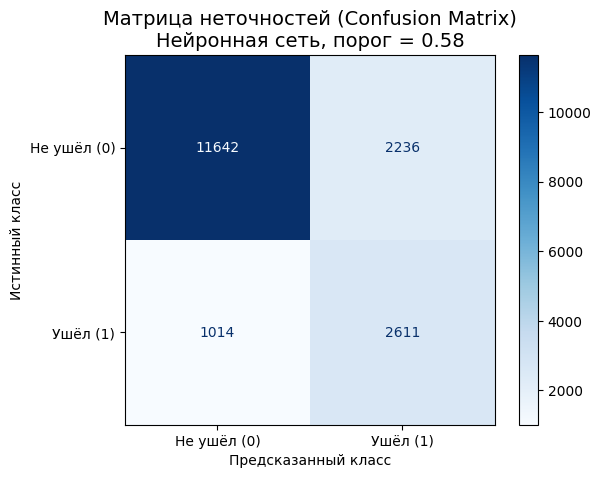

Матрица неточностей:
[[11642  2236]
 [ 1014  2611]]

Расшифровка:
True Negative  (TN): 11642  → правильно предсказали, что клиент НЕ уйдёт
False Positive (FP): 2236  → ошибочно предсказали отток
False Negative (FN): 1014  → пропустили клиента, который ушёл
True Positive  (TP): 2611  → правильно предсказали отток


In [111]:
# Лучшая модель + порог 0.58
THRESHOLD = 0.58
proba = best_nn_model.predict(test_points_scaled).flatten()
y_pred = (proba >= THRESHOLD).astype(int)

# Построение матрицы неточностей
cm = confusion_matrix(test_values, y_pred)

# Красивый вывод
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Не ушёл (0)', 'Ушёл (1)'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица неточностей (Confusion Matrix)\nНейронная сеть, порог = 0.58', 
          fontsize=14)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.grid(False)
plt.show()

# Текстовый вывод для удобства
print("Матрица неточностей:")
print(cm)
print("\nРасшифровка:")
print(f"True Negative  (TN): {cm[0,0]}  → правильно предсказали, что клиент НЕ уйдёт")
print(f"False Positive (FP): {cm[0,1]}  → ошибочно предсказали отток")
print(f"False Negative (FN): {cm[1,0]}  → пропустили клиента, который ушёл")
print(f"True Positive  (TP): {cm[1,1]}  → правильно предсказали отток")